### 01. Import Required libraries

In [76]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

### 02. Load the datset

In [77]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)

In [78]:
X

array([[-6.59633932, -7.13901457],
       [-6.13753182, -6.58081701],
       [ 5.19820575,  2.04917508],
       ...,
       [ 3.69047995,  4.60555175],
       [ 4.03036663,  1.78619838],
       [-7.44179522, -7.08933147]], shape=(1000, 2))

In [79]:
y

array([2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0,
       2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
       2, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1,
       1, 2, 0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2,
       0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2,
       1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1,
       1, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1,
       2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2,
       2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 2, 1,
       2, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2,

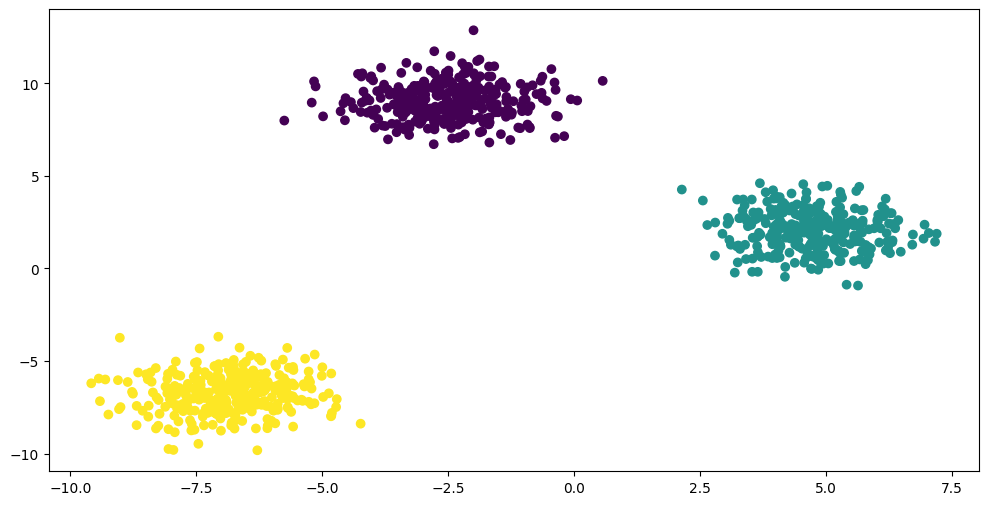

In [80]:
plt.figure(figsize=(12,6))
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

### 03. Standardization-feature scaling technique

In [81]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [84]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### 04. Model Training

In [85]:
from sklearn.cluster import KMeans

In [86]:
# Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [87]:
wcss

[1339.9999999999995,
 424.779504284127,
 43.53781728348884,
 37.73043285961998,
 31.648009260090646,
 25.8524318368544,
 23.840475851773895,
 21.586628075308333,
 19.227032077049273,
 18.89793481780136]

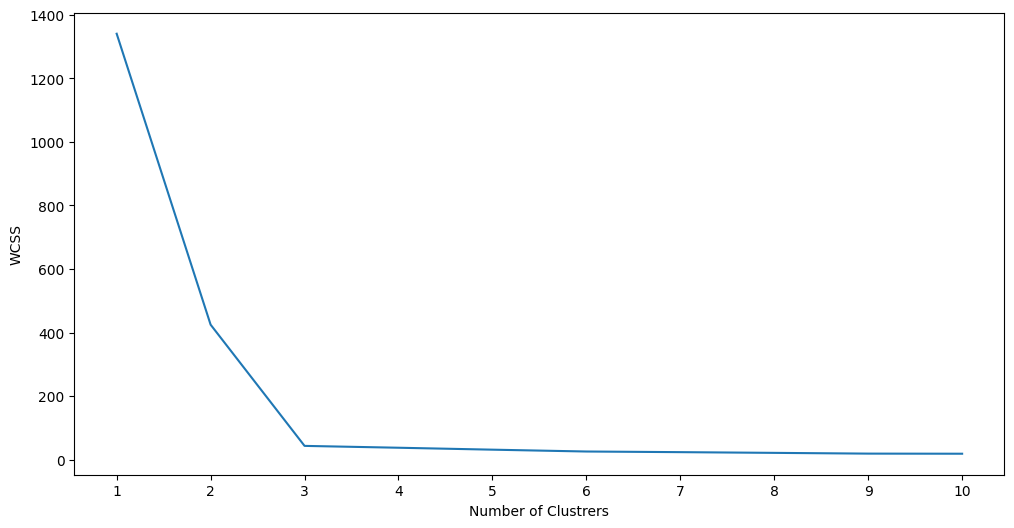

In [88]:
# Plot elbow curve
plt.figure(figsize=(12,6))
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [89]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [90]:
kmeans.fit_predict(X_train_scaled)

array([1, 0, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 1, 2,
       0, 2, 2, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2, 1, 2, 1, 1, 0, 0, 0, 2, 1,
       1, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2,
       0, 0, 0, 1, 1, 0, 0, 1, 2, 2, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2,
       2, 2, 2, 0, 1, 2, 2, 0, 2, 2, 0, 1, 2, 1, 2, 1, 0, 2, 2, 0, 0, 1,
       2, 0, 2, 0, 2, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 1, 1,
       2, 1, 1, 0, 2, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 2, 2, 1, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 2, 0, 0, 2, 2, 0, 2,
       1, 1, 2, 1, 2, 1, 2, 0, 0, 0, 2, 1, 2, 2, 0, 0, 0, 1, 1, 2, 0, 1,
       0, 0, 1, 2, 0, 1, 1, 2, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 1, 0, 2, 0,
       0, 0, 1, 2, 0, 0, 2, 0, 1, 2, 2, 0, 2, 2, 1, 1, 0, 0, 2, 0, 2, 0,
       1, 2, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 1, 1, 0, 1, 2, 0, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 1, 0, 2, 2, 0, 0, 0, 0, 1, 2,

In [91]:
y_pred=kmeans.predict(X_test_scaled)
y_pred

array([2, 0, 0, 1, 2, 0, 1, 2, 1, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 2,
       2, 1, 1, 1, 0, 2, 1, 2, 0, 1, 1, 0, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1,
       2, 0, 1, 1, 2, 0, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2, 0, 1, 0, 2,
       2, 0, 0, 2, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 2, 0, 0, 0, 1, 2, 0, 1, 2, 2, 0, 2, 0, 0, 2, 2, 0, 1,
       1, 1, 2, 0, 1, 0, 2, 2, 1, 0, 1, 0, 2, 1, 1, 2, 2, 2, 0, 0, 1, 1,
       0, 0, 2, 0, 2, 2, 2, 1, 2, 2, 1, 1, 0, 0, 2, 0, 0, 0, 1, 2, 0, 1,
       2, 2, 0, 0, 1, 1, 1, 2, 0, 1, 2, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1, 1,
       2, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 0, 2, 2, 2, 0, 1, 2, 0, 2,
       0, 2, 1, 2, 1, 1, 2, 2, 2, 1, 0, 2, 2, 2, 0, 1, 0, 1, 1, 2, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 2, 1,
       0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 1, 0, 0, 1, 2, 1,
       2, 0, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 1, 0,

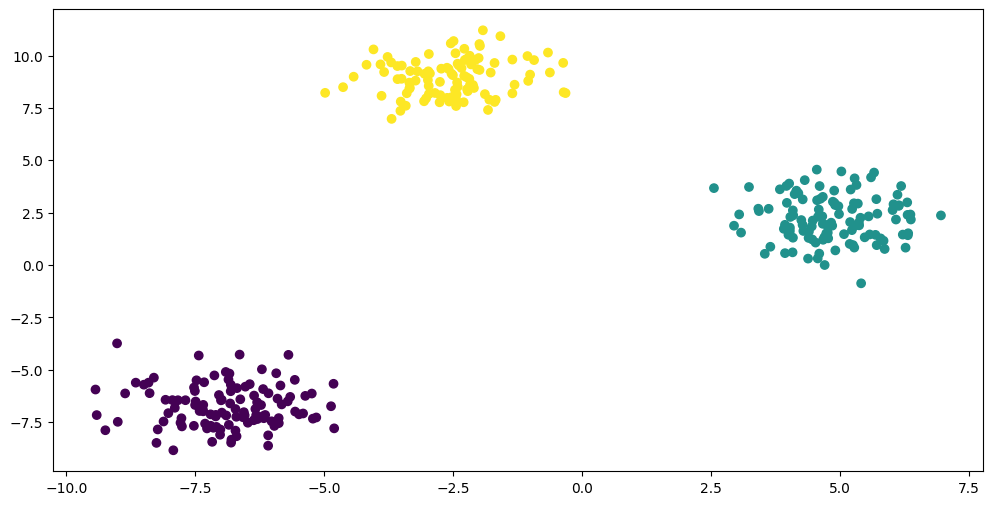

In [92]:
plt.figure(figsize=(12,6))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

In [93]:
## Validating the k value
## Kneelocator
## Silhoutee scoring

In [94]:
from kneed import KneeLocator

In [95]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [96]:
kl.elbow

np.int64(3)

In [97]:
# Silhoutte score
from sklearn.metrics import silhouette_score

In [98]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [99]:
silhouette_coefficients

[0.6857199772837788,
 0.842476016737992,
 0.6747876113372735,
 0.6570445351290144,
 0.3545890294484973,
 0.3443301289339814,
 0.3434877599193647,
 0.3190867114203017,
 0.33540401372783685]

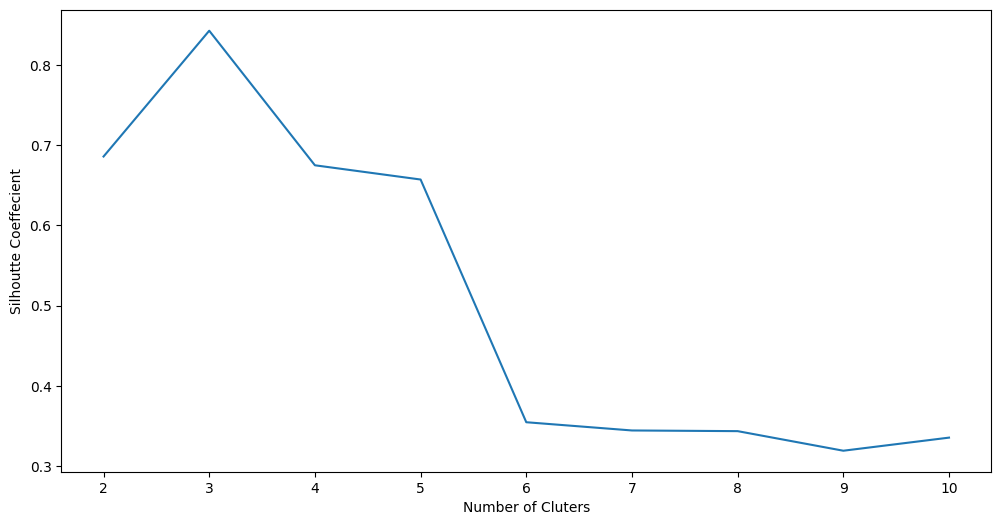

In [100]:
# Plotting silhouette score
plt.figure(figsize=(12,6))
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()